In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load cleaned data
df = pd.read_csv('C:\\Users\\Sathyavati\\Market_Share_model\\data\\cleaned\\os_model_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print('Shape:', df.shape) 
df.head()

Shape: (155, 5)


,Date,x,y,dx,dy
0,2013-02-01,0.3690,0.2721,0.0003,0.0136
1,2013-03-01,0.3723,0.2714,0.0033,-0.0007
2,2013-04-01,0.3834,0.2646,0.0111,-0.0068
3,2013-05-01,0.3827,0.2586,-0.0007,-0.0060
4,2013-06-01,0.3793,0.2509,-0.0034,-0.0077


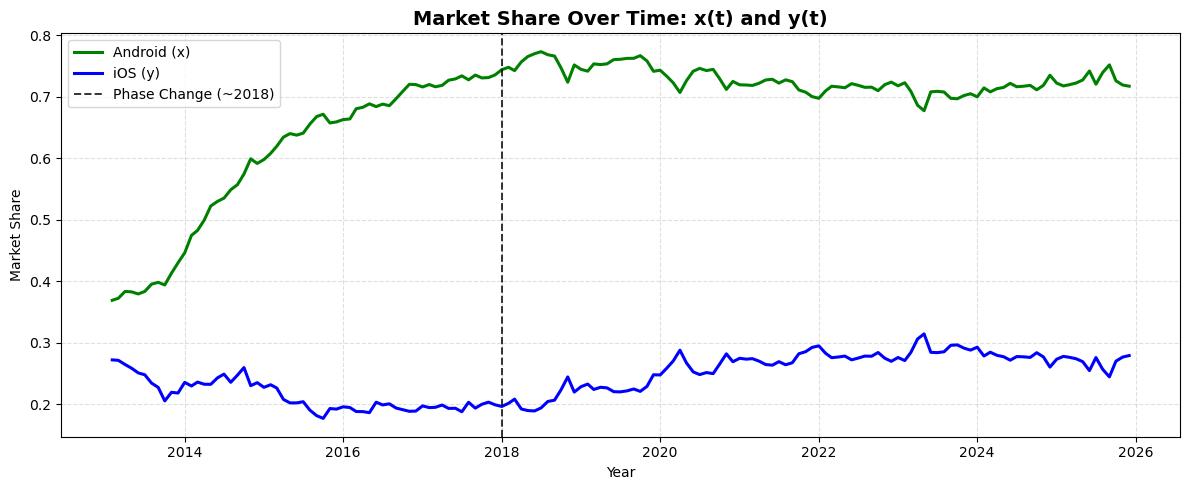

In [28]:
#Plot x(t) and y(t)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Date'], df['x'], color='green', linewidth=2.2, label='Android (x)')
ax.plot(df['Date'], df['y'], color='blue', linewidth=2.2, label='iOS (y)')

ax.axvline(pd.Timestamp('2018-01-01'), color='black', linewidth=1.4,
           linestyle='--', alpha=0.8, label='Phase Change (~2018)')

ax.set_title('Market Share Over Time: x(t) and y(t)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Market Share')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



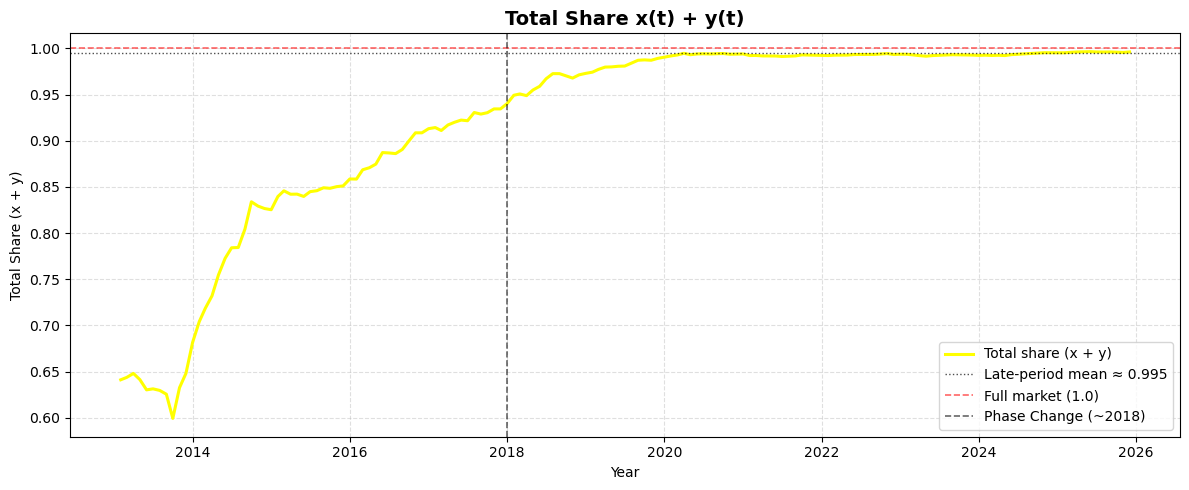

In [27]:
#Plot total share (x + y)
df['total'] = df['x'] + df['y']

early_mean = df['total'].iloc[:20].mean()
late_mean  = df['total'].iloc[-20:].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Date'], df['total'], color='yellow', linewidth=2.2, label='Total share (x + y)')

ax.axhline(late_mean, color='black', linewidth=1, linestyle=':',
           alpha=0.7, label=f'Late-period mean ≈ {late_mean:.3f}')

ax.axhline(1.0, color='red', linewidth=1.2, linestyle='--',
           alpha=0.6, label='Full market (1.0)')

ax.axvline(pd.Timestamp('2018-01-01'), color='black', linewidth=1.2,
           linestyle='--', alpha=0.6, label='Phase Change (~2018)')
ax.set_title('Total Share x(t) + y(t)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Share (x + y)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

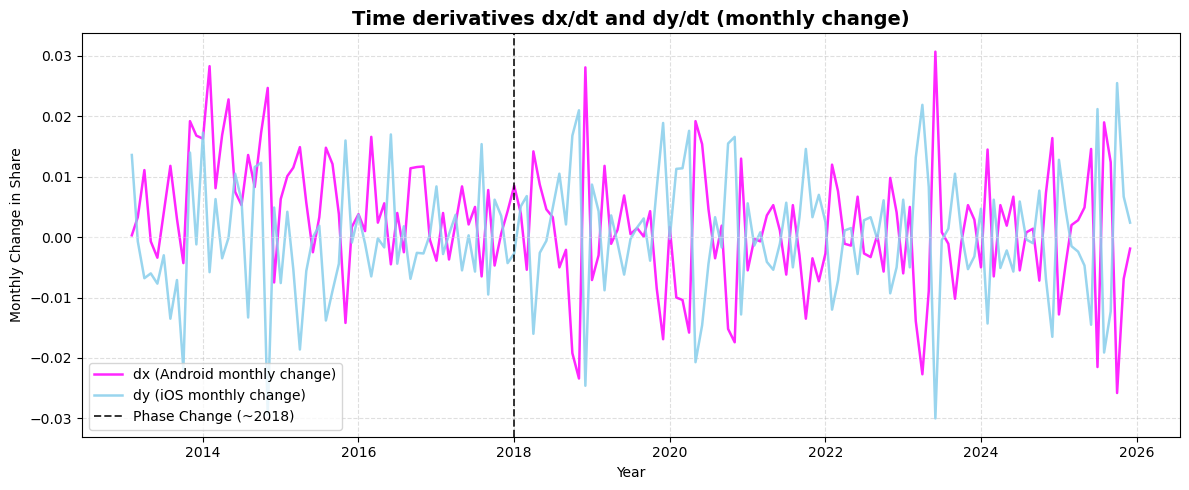

In [21]:
#Task 3 — Plot diff(x) and diff(y)
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['Date'], df['dx'], color='magenta', linewidth=1.8, alpha=0.85, label='dx (Android monthly change)')
ax.plot(df['Date'], df['dy'], color='skyblue', linewidth=1.8, alpha=0.85, label='dy (iOS monthly change)')

ax.axhline(0, color='white', linewidth=0.8, linestyle='-', alpha=0.3)

ax.axvline(pd.Timestamp('2018-01-01'), color='black', linewidth=1.4,
           linestyle='--', alpha=0.8, label='Phase Change (~2018)')

ax.set_title('Time derivatives dx/dt and dy/dt (monthly change)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Monthly Change in Share')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

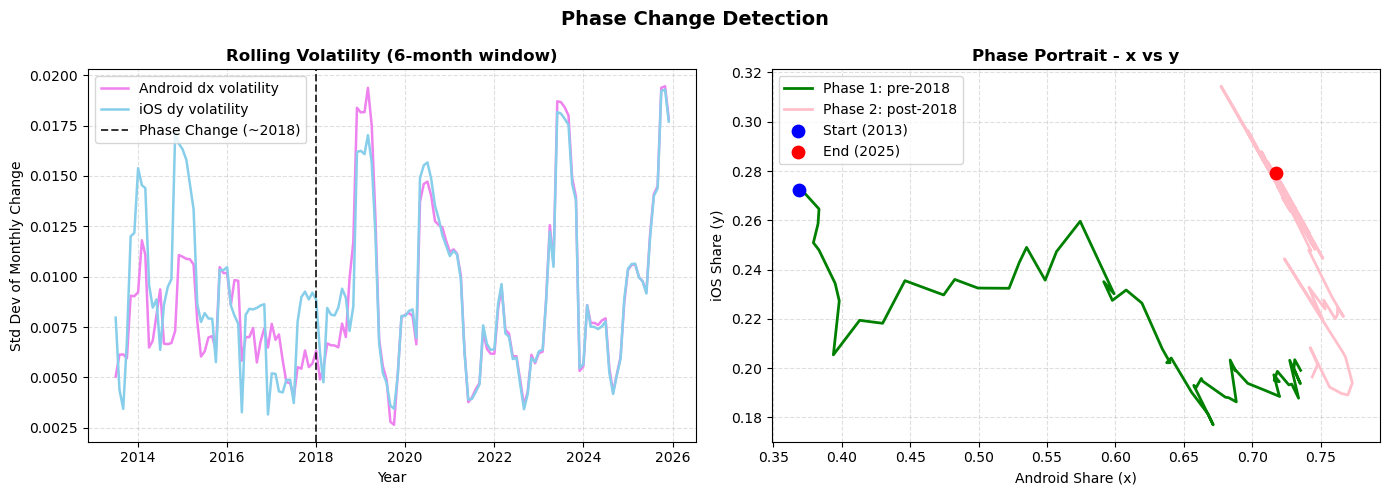

In [14]:
#Task 4 — Detect phase change
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

phase_year = pd.Timestamp('2018-01-01')

#Plot 1: Rolling Volatility 
ax1 = axes[0]

roll_x = df['dx'].rolling(6).std()
roll_y = df['dy'].rolling(6).std()

ax1.plot(df['Date'], roll_x, color='violet', linewidth=1.8, label='Android dx volatility')
ax1.plot(df['Date'], roll_y, color='skyblue', linewidth=1.8, label='iOS dy volatility')

ax1.axvline(phase_year, color='black', linewidth=1.4,
            linestyle='--', alpha=0.8, label='Phase Change (~2018)')
ax1.set_title('Rolling Volatility (6-month window)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Std Dev of Monthly Change')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

#Plot 2: Phase Portrait 
ax2 = axes[1]

mask1 = df['Date'] < phase_year
mask2 = df['Date'] >= phase_year

ax2.plot(df.loc[mask1, 'x'], df.loc[mask1, 'y'], color='green', linewidth=2, label='Phase 1: pre-2018')
ax2.plot(df.loc[mask2, 'x'], df.loc[mask2, 'y'], color='pink', linewidth=2, label='Phase 2: post-2018')
ax2.scatter(df['x'].iloc[0],  df['y'].iloc[0],  color='blue',   s=80, zorder=5, label='Start (2013)')
ax2.scatter(df['x'].iloc[-1], df['y'].iloc[-1], color='red', s=80, zorder=5, label='End (2025)')

ax2.set_title('Phase Portrait - x vs y', fontsize=12, fontweight='bold')
ax2.set_xlabel('Android Share (x)')
ax2.set_ylabel('iOS Share (y)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Phase Change Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()